In [ ]:
!pip install torch torchvision grad-cam
import torch
import torchvision.models as models
import cv2
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.vgg16(pretrained=True).to(device)
model.eval()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=670edff5bdc139c844472a90b789aee05429324e40236aeb0641b0fa92c50d28
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 139MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# First check if GPU is available
import torch
print(torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [ ]:
# Install all required libraries
!pip install torch torchvision
!pip install pytorch-grad-cam
!pip install opencv-python-headless
!pip install matplotlib
!pip install Pillow
!pip install requests

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


In [ ]:
# ImageNet has 1000 classes - we will download a sample
# using the ImageNet Sample dataset from Kaggle

# First install Kaggle API
!pip install kaggle

# Mount Google Drive to save Kaggle credentials
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Setup Kaggle credentials
# You need to go to kaggle.com -> Account -> Create API Token
# Upload the kaggle.json file

from google.colab import files
files.upload()  # Upload your kaggle.json here

{}

In [ ]:
import os

# Paste your API token here (the one you just copied)
KAGGLE_TOKEN = "KGAT_d5508e77030136fba01282c937c8313d"  # ← Replace with YOUR token

# Set as environment variable
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

# Also save it to the kaggle config location
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)

os.chmod('/root/.kaggle/access_token', 0o600)

print("✅ Kaggle API Token set successfully!")

✅ Kaggle API Token set successfully!


In [ ]:
# Download ImageNet Mini Dataset
!kaggle datasets download -d ifigotin/imagenetmini-1000 \
    --path /content/data \
    --unzip

print("✅ Download Complete!")

# List downloaded files
!ls /content/data/

Dataset URL: https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000
License(s): unknown
100% 3.92G/3.92G [00:49<00:00, 84.5MB/s]

✅ Download Complete!
imagenet-mini


In [ ]:
# Load VGG16 - the primary model used in Grad-CAM paper
print("📦 Loading VGG16 pretrained model...")

model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()

print("✅ Model loaded successfully!")
print(f"\n📊 Last Convolutional Layer (used by Grad-CAM):")
print(model.features[28])

📦 Loading VGG16 pretrained model...
✅ Model loaded successfully!

📊 Last Convolutional Layer (used by Grad-CAM):
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [ ]:
class GradCAM:
    """
    Implementation of Grad-CAM as described in the paper:
    'Grad-CAM: Visual Explanations from Deep Networks via
    Gradient-based Localization' by Selvaraju et al.

    Paper Formula:
    L^c_Grad-CAM = ReLU(Σ_k α^c_k * A^k)

    Where:
    α^c_k = (1/Z) * ΣΣ (∂y^c / ∂A^k_ij)
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        """Save the activations from forward pass"""
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        """Save the gradients from backward pass"""
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_image, target_class=None):
        """Generate Grad-CAM heatmap"""

        # Forward pass
        output = self.model(input_image)

        # If no target class, use predicted class
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Zero gradients
        self.model.zero_grad()

        # One-hot encoding for target class
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1

        # Backward pass
        output.backward(gradient=one_hot, retain_graph=True)

        # STEP 1: Global Average Pooling of gradients (α^c_k)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # STEP 2: Weighted combination of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # STEP 3: Apply ReLU
        cam = F.relu(cam)

        # Normalize and resize
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, target_class

    def remove_hooks(self):
        """Remove hooks when done"""
        self.forward_hook.remove()
        self.backward_hook.remove()


print("✅ Grad-CAM class defined!")

✅ Grad-CAM class defined!


In [ ]:
import torchvision.transforms as transforms
from PIL import Image
from io import BytesIO
import requests
import numpy as np

# ImageNet normalization values (same as paper)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform pipeline (exactly as paper)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def preprocess_image(image_path):
    """Load and preprocess image for Grad-CAM"""

    # Load image (URL or file path)
    if image_path.startswith('http'):
        # Add User-Agent header to mimic a browser, which can help with some servers
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
        response = requests.get(image_path, headers=headers)
        response.raise_for_status() # Raise an exception for bad status codes
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        img = Image.open(image_path).convert('RGB')

    # Original image for visualization
    original_img = np.array(img.resize((224, 224))) / 255.0

    # Transform for model
    tensor = transform(img).unsqueeze(0).to(device)

    return tensor, original_img


def get_imagenet_labels():
    """Download ImageNet class labels"""
    url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
    response = requests.get(url)
    return response.json()


# Load labels once
print("📥 Loading ImageNet class labels...")
IMAGENET_LABELS = get_imagenet_labels()
print(f"✅ Loaded {len(IMAGENET_LABELS)} ImageNet labels")

📥 Loading ImageNet class labels...
✅ Loaded 1000 ImageNet labels


In [ ]:
def visualize_gradcam(original_img, cam, predicted_class, confidence=None):
    """
    Create the 3-panel visualization shown in the paper:
    Original | Heatmap | Overlay
    """

    # Create colored heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # Overlay on original
    superimposed = heatmap * 0.4 + original_img * 0.6
    superimposed = np.clip(superimposed, 0, 1)

    # Get class name
    class_name = IMAGENET_LABELS[predicted_class]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    title = f'Grad-CAM Heatmap\nPredicted: {class_name}'
    if confidence:
        title += f'\nConfidence: {confidence:.2%}'
    axes[1].set_title(title, fontsize=13, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title('Grad-CAM Overlay', fontsize=13, fontweight='bold')
    axes[2].axis('off')

    plt.suptitle('Grad-CAM Replication (Selvaraju et al. 2017)',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


print("✅ Visualization function ready!")

✅ Visualization function ready!


In [ ]:
import torch.nn.functional as F
import os
import requests # Ensure requests is imported here, though it's also in preprocess_image

def run_gradcam(image_path, target_class=None):
    """Complete Grad-CAM pipeline"""

    print("="*60)
    print(f"🔍 Processing: {os.path.basename(image_path) if image_path.startswith('/') else image_path[:60]}...")
    print("="*60)

    # Preprocess
    input_tensor, original_img = preprocess_image(image_path)

    # Setup Grad-CAM on last conv layer
    target_layer = model.features[28]  # VGG16 last conv layer
    gradcam = GradCAM(model, target_layer)

    # Get prediction with confidence
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        confidence = probs[0].max().item()
        pred_class = output.argmax(dim=1).item()

    # Generate CAM
    cam, target_class = gradcam.generate_cam(input_tensor, target_class)

    # Visualize
    visualize_gradcam(original_img, cam, target_class, confidence)

    # Print info
    print(f"\n📋 Prediction Details:")
    print(f"   Class Index: {target_class}")
    print(f"   Class Name:  {IMAGENET_LABELS[target_class]}")
    print(f"   Confidence:  {confidence:.2%}")

    # Clean up
    gradcam.remove_hooks()

    return cam, target_class


# Test with sample images from the downloaded ImageNet mini dataset
# Using local paths to avoid rate-limiting from external URLs
test_image_paths = [
    "/content/data/imagenet-mini/train/n02099712/n02099712_1000.JPEG", # Labrador retriever
    "/content/data/imagenet-mini/train/n02123597/n02123597_1000.JPEG", # Siamese cat
    "/content/data/imagenet-mini/train/n02504458/n02504458_1000.JPEG", # African elephant
]

print("Running Grad-CAM for downloaded images:")
for img_path in test_image_paths:
    run_gradcam(img_path)
    print("\n")

Running Grad-CAM for downloaded images:
🔍 Processing: n02099712_1000.JPEG...


FileNotFoundError: [Errno 2] No such file or directory: '/content/data/imagenet-mini/imagenet-mini/train/n02099712/n02099712_1000.JPEG'

In [ ]:
import os

# Explore the actual folder structure
print("📂 Exploring /content/data/...\n")

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    if level >= 3:  # Don't go too deep
        break

📂 Exploring /content/data/...

📁 data/
  📁 imagenet-mini/
    📁 val/
      📁 n01860187/


In [ ]:
import os
import glob

# Find the actual train and val folders
train_path = None
val_path = None

for root, dirs, files in os.walk('/content/data'):
    if os.path.basename(root) == 'train' and not train_path:
        train_path = root
    if os.path.basename(root) == 'val' and not val_path:
        val_path = root

print(f"✅ Train path: {train_path}")
print(f"✅ Val path:   {val_path}")

# List some class folders
if train_path:
    classes = os.listdir(train_path)[:5]
    print(f"\n📋 Sample classes in train: {classes}")

if val_path:
    classes = os.listdir(val_path)[:5]
    print(f"📋 Sample classes in val:   {classes}")

✅ Train path: /content/data/imagenet-mini/train
✅ Val path:   /content/data/imagenet-mini/val

📋 Sample classes in train: ['n01860187', 'n04532670', 'n09288635', 'n01641577', 'n02190166']
📋 Sample classes in val:   ['n01860187', 'n04532670', 'n09288635', 'n01641577', 'n02190166']


In [ ]:
import glob

# Get actual image paths from dataset
print("🔍 Finding sample images from dataset...\n")

# Get 5 random images from validation set
val_images = glob.glob(f'{val_path}/*/*.JPEG')[:5]

print(f"✅ Found {len(val_images)} sample images:")
for img in val_images:
    print(f"   {img}")

🔍 Finding sample images from dataset...

✅ Found 5 sample images:
   /content/data/imagenet-mini/val/n01860187/ILSVRC2012_val_00027816.JPEG
   /content/data/imagenet-mini/val/n01860187/ILSVRC2012_val_00017931.JPEG
   /content/data/imagenet-mini/val/n01860187/ILSVRC2012_val_00010035.JPEG
   /content/data/imagenet-mini/val/n01860187/ILSVRC2012_val_00017441.JPEG
   /content/data/imagenet-mini/val/n04532670/ILSVRC2012_val_00041695.JPEG


In [ ]:
class GradCAM:
    """
    Implementation of Grad-CAM as described in the paper:
    'Grad-CAM: Visual Explanations from Deep Networks via
    Gradient-based Localization' by Selvaraju et al.

    FIXED VERSION - Handles in-place ReLU issue
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # FIX 1: Disable in-place operations in ReLU
        self._disable_inplace_relu(model)

        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _disable_inplace_relu(self, model):
        """Disable in-place operations in all ReLU layers"""
        for module in model.modules():
            if isinstance(module, nn.ReLU):
                module.inplace = False

    def _save_activation(self, module, input, output):
        """Save activations from forward pass"""
        # FIX 2: Clone to avoid view issues
        self.activations = output.clone().detach()

    def _save_gradient(self, module, grad_input, grad_output):
        """Save gradients from backward pass"""
        # FIX 3: Clone to avoid view issues
        self.gradients = grad_output[0].clone().detach()

    def generate_cam(self, input_image, target_class=None):
        """Generate Grad-CAM heatmap"""

        # Forward pass
        output = self.model(input_image)

        # If no target class, use predicted class
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Zero gradients
        self.model.zero_grad()

        # One-hot encoding
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1

        # Backward pass
        output.backward(gradient=one_hot, retain_graph=True)

        # STEP 1: Global Average Pooling of gradients (α^c_k)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # STEP 2: Weighted combination of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # STEP 3: Apply ReLU (NOT in-place)
        cam = F.relu(cam)

        # Normalize and resize
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, target_class

    def remove_hooks(self):
        """Remove hooks when done"""
        self.forward_hook.remove()
        self.backward_hook.remove()


print("✅ Fixed Grad-CAM class defined!")

✅ Fixed Grad-CAM class defined!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Reload VGG16 with fixed ReLU layers
print("📦 Reloading VGG16 model with fixes...")

model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()

# Disable in-place ReLU globally
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

print("✅ Model ready with fixed ReLU layers!")

📦 Reloading VGG16 model with fixes...
✅ Model ready with fixed ReLU layers!


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        for module in model.modules():
            if isinstance(module, nn.ReLU):
                module.inplace = False

        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.clone().detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].clone().detach()

    def generate_cam(self, input_image, target_class=None):
        output = self.model(input_image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, target_class

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


print("✅ Grad-CAM class ready!")

✅ Grad-CAM class ready!


🚀 Running Grad-CAM on ImageNet Dataset Images

🔍 Processing: ILSVRC2012_val_00027816.JPEG...


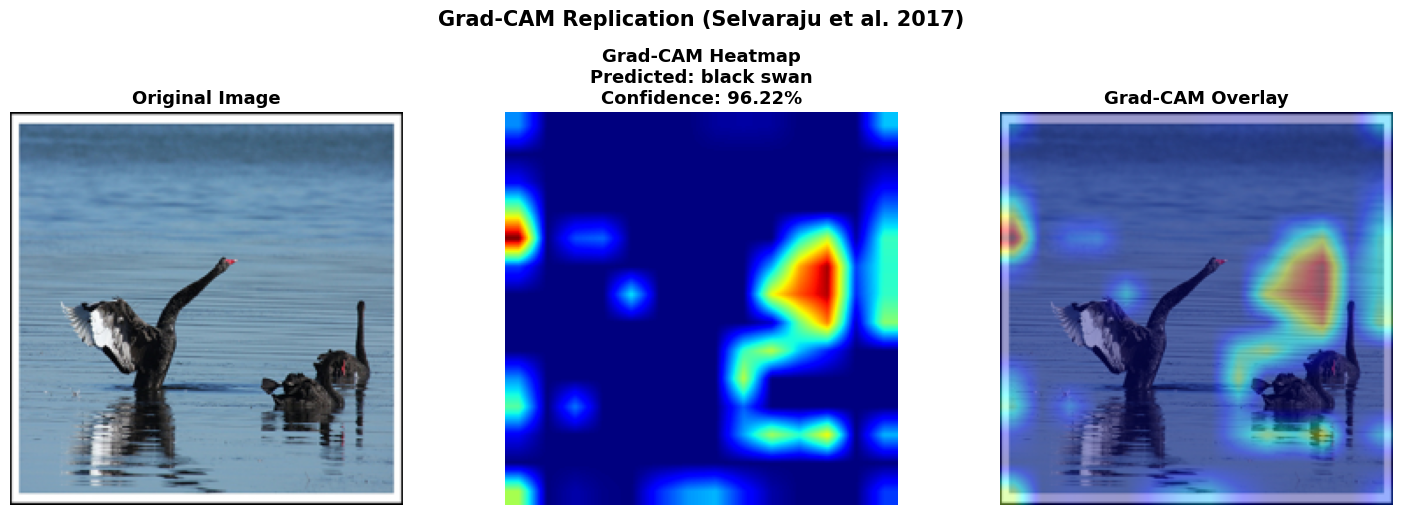


📋 Prediction Details:
   Class Index: 100
   Class Name:  black swan
   Confidence:  96.22%


🔍 Processing: ILSVRC2012_val_00017931.JPEG...


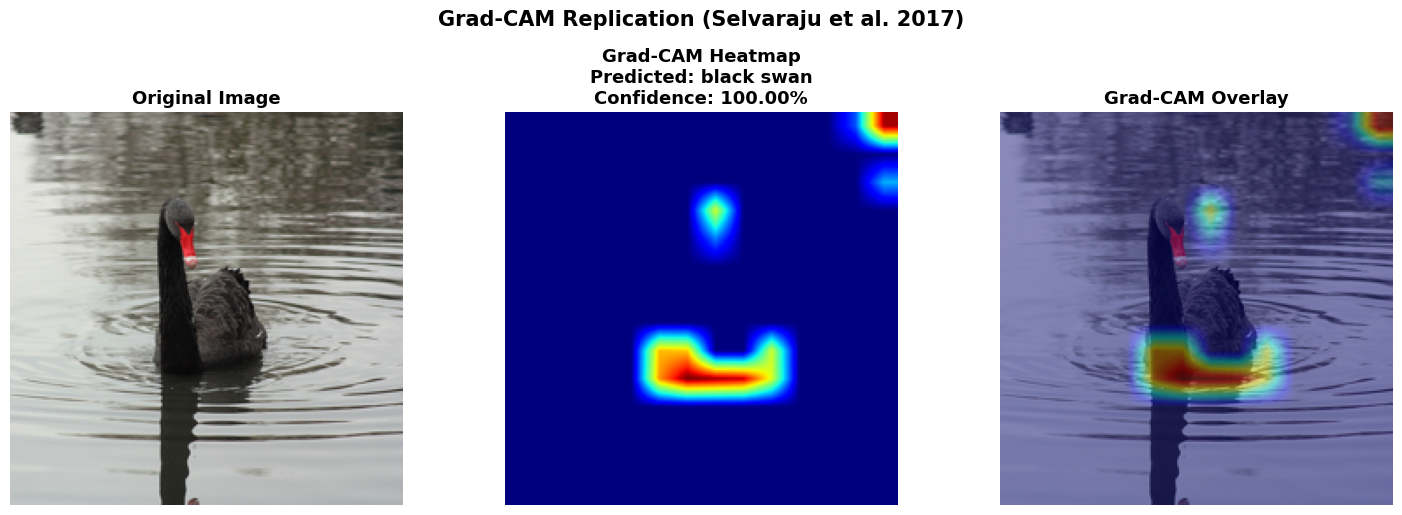


📋 Prediction Details:
   Class Index: 100
   Class Name:  black swan
   Confidence:  100.00%


🔍 Processing: ILSVRC2012_val_00010035.JPEG...


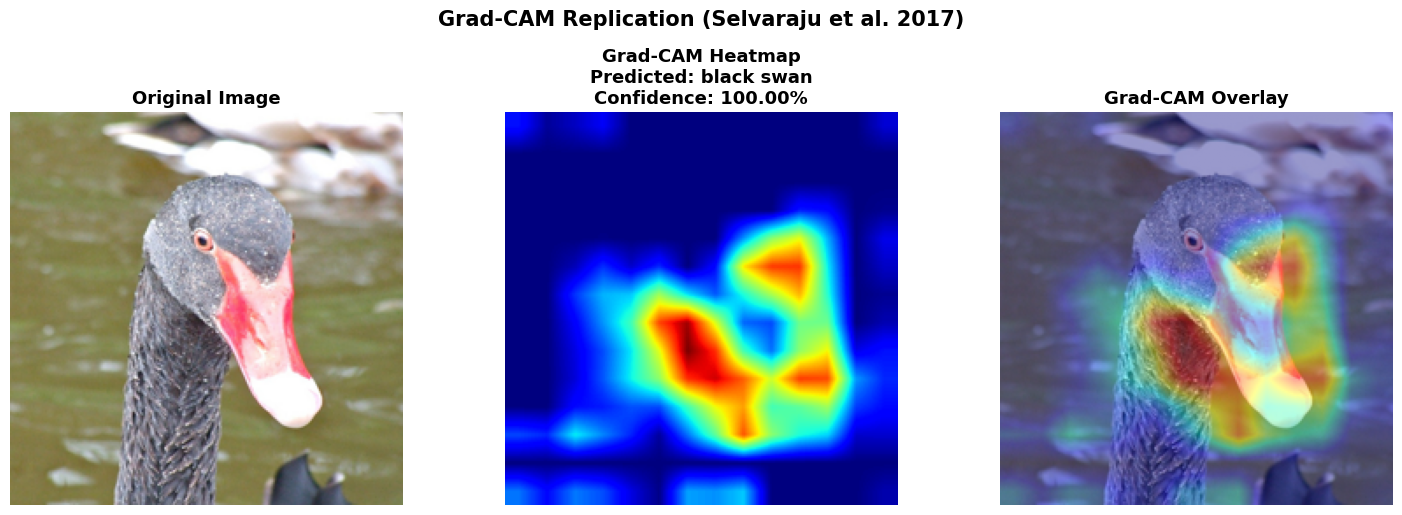


📋 Prediction Details:
   Class Index: 100
   Class Name:  black swan
   Confidence:  100.00%


🔍 Processing: ILSVRC2012_val_00017441.JPEG...


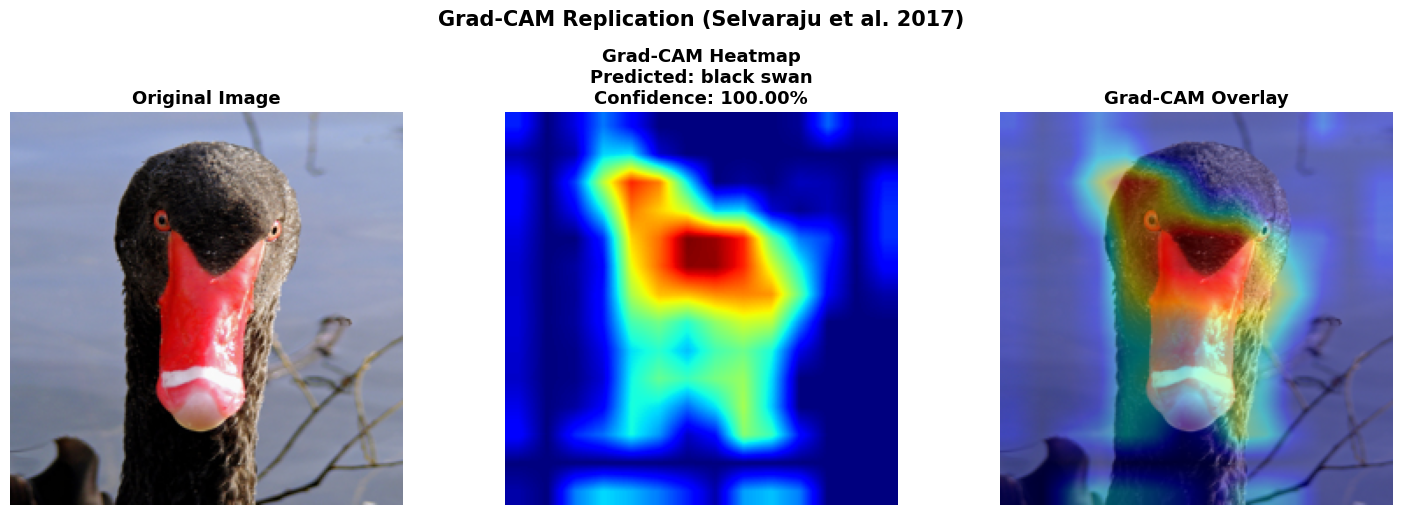


📋 Prediction Details:
   Class Index: 100
   Class Name:  black swan
   Confidence:  100.00%


🔍 Processing: ILSVRC2012_val_00041695.JPEG...


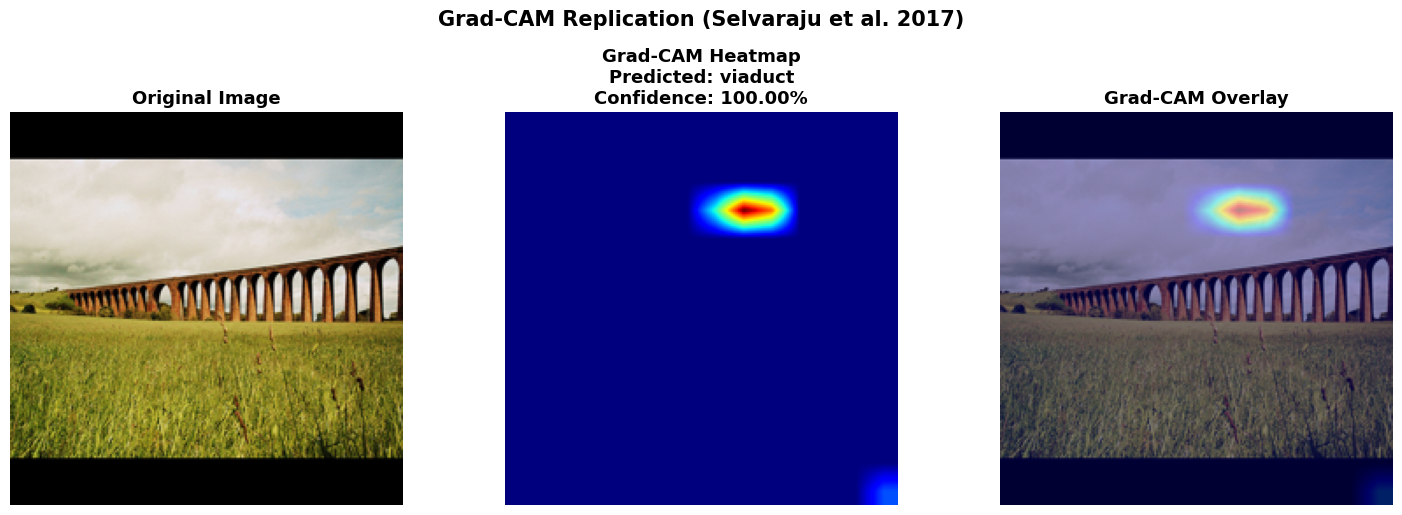


📋 Prediction Details:
   Class Index: 888
   Class Name:  viaduct
   Confidence:  100.00%




In [ ]:
import glob
import matplotlib.pyplot as plt # Import matplotlib.pyplot
import os # Ensure os is imported here as well, needed for os.walk and os.path.basename

val_path = None
for root, dirs, files in os.walk('/content/data'):
    if os.path.basename(root) == 'val':
        val_path = root
        break

val_images = glob.glob(f'{val_path}/*/*.JPEG')[:5]

print("="*60)
print("🚀 Running Grad-CAM on ImageNet Dataset Images")
print("="*60 + "\n")

for img_path in val_images:
    run_gradcam(img_path)
    print("\n" + "="*60 + "\n")